In [66]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches

In [67]:
#中间矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m, B, a):
    return (m + 4*B/(a**2)) * sz

def h_x(B, a, A):
    return ((-B/(a**2))*sz - (1j/2)*A*sx) 
    
def h_y(B, a, A, Bz,xweizhi):
    return ((-B/(a**2))*sz - (1j/2)*A*sy) * np.exp(-(2*np.pi*1j*a**2)*Bz*xweizhi)

def h_onstie(m, B, a, u):
    return h_k(m, B, a) - u*s0

def t_x(B, a, A):
    return h_x(B, a, A)

def t_y(B, a, A, Bz, xweizhi):
    return h_y(B, a, A, Bz, xweizhi)


def H_onstie(m, B, a, u_set, xshumu, Nd, A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i] = h_onstie(m, B, a, u_set[i])

        if i < xshumu - 1:
            H[i][i+1] = t_x(B, a, A)

        if i > 0:
            H[i][i-1] = t_x(B, a, A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B, a, A, xshumu, Nd,Bz):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        xweizhi=i
        H[i][i] = t_y(B, a, A, Bz,xweizhi)

    H = np.block(H)
    return H


m = -0.5       # 质量项
A = 1.0        # 费米速度项
B = 0.5        # 二阶动量项
Bz = 0.0  # 磁场
Ex = 0         # 电场相关

a = 1          # 晶格常数
yshumu = 25
xshumu = 16

uS = 0
uS_set = []
for i in range(xshumu):
    uS_set.append(uS - Ex * 1 * (i - xshumu/2))

uS_set_base = np.array(uS_set)

Nd = 2


H_q=H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)

H_q_list = []
for i in range(yshumu):
    H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
    H_q_list.append(H_q_i)

T_21 = H_hop(B, a, A, xshumu, Nd,Bz)



In [ ]:
#四条引线
# 构建横向引线（沿 x 延伸）单个切片内部的哈密顿量（切片沿 y 展开）
def H_onstie_lead_y(m, B, a, mu_set, yshumu_lead, Nd, A, Bz, x_weizhi_edge):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu_lead)] for _ in range(yshumu_lead)]

    for i in range(yshumu_lead):
        # 注意：这里的 on-site 依然是你定义的 h_onstie
        H[i][i] = h_onstie(m, B, a, mu_set[i])

        if i < yshumu_lead - 1:
            # 切片内部沿着 y 轴，所以跳跃是 t_y
            H[i][i+1] = t_y(B, a, A, Bz, x_weizhi_edge)

        if i > 0:
            H[i][i-1] = t_y(B, a, A, Bz, x_weizhi_edge).conj().T
    
    return np.block(H)

# 构建横向引线（沿 x 延伸）层与层之间的跳跃矩阵
def T_hop_lead_x(B, a, A, yshumu_lead, Nd):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu_lead)] for _ in range(yshumu_lead)]

    for i in range(yshumu_lead):
        # 层与层之间沿着 x 轴延伸，所以跳跃是 t_x
        H[i][i] = t_x(B, a, A)

    return np.block(H)
    
yshumu_1=2
mu_1 = 0
mu_1_set = []
for i in range(yshumu_1):
    mu_1_set.append(mu_1)
mu_1_set = np.array(mu_1_set)
H_y1=H_onstie(m, B, a, mu_1_set, yshumu_1, Nd, A)
T_21_y1 = H_hop(B, a, A, yshumu_1, Nd, 0)

T_c_y1 = np.zeros((Nd * yshumu_1, Nd * yshumu), dtype=complex)
T_c_y1[:, Nd*7 :Nd *(7+yshumu_1)] = T_21_y1.conj().T



yshumu_2=2
mu_2 = 0
mu_2_set = []
for i in range(yshumu_2):
    mu_2_set.append(mu_2)
mu_2_set = np.array(mu_2_set)
H_y2=H_onstie(m, B, a, mu_2_set, yshumu_2, Nd, A)
T_21_y2 = H_hop(B, a, A, yshumu_2, Nd, 0)

T_c_y2 = np.zeros((Nd * yshumu_2, Nd * yshumu), dtype=complex)
T_c_y2[:, Nd*(7+9) :Nd *(7+9+yshumu_2)] = T_21_y2.conj().T


yshumu_3=2
mu_3 = 0
mu_3_set = []
for i in range(yshumu_3):
    mu_3_set.append(mu_3)
mu_3_set = np.array(mu_3_set)
H_y3=H_onstie(m, B, a, mu_3_set, yshumu_3, Nd, A)
T_21_y3 = H_hop(B, a, A, yshumu_3, Nd, 0).conj().T

T_c_y3 = np.zeros((Nd * yshumu_3,  Nd * yshumu), dtype=complex)
T_c_y3[:, Nd*7 :Nd *(7+yshumu_3)] = T_21_y3.conj().T


yshumu_4=2
mu_4 = 0
mu_4_set = []
for i in range(yshumu_4):
    mu_4_set.append(mu_4)
mu_4_set = np.array(mu_4_set)
H_y4=H_onstie(m, B, a, mu_4_set, yshumu_4, Nd, A)
T_21_y4 = H_hop(B, a, A, yshumu_4, Nd, 0).conj().T

T_c_y4 = np.zeros((Nd * yshumu_3,  Nd * yshumu), dtype=complex)
T_c_y4[:, Nd*(7+9) :Nd *(7+9+yshumu_3)] = T_21_y4.conj().T

In [69]:
## 两边纳米线 
t = 1
tc = 1 * t
mu = 0
weidu = 2
kuandu = 16   # 电极的横向宽度
Nd = 2        # 2x2 正常态

def H_onsite_1(t,mu ,weidu):
    HX_block = -(mu - 2*weidu*t)*s0 
    return HX_block

def H_hop_1(t):
    # 纯粹的最近邻跳跃
    H_X_right_to_left_hop_block = -t * s0
    return H_X_right_to_left_hop_block

def H_onsite_2(t,mu, weidu, kuandu):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(kuandu)] for _ in range(kuandu)]

    for i in range(kuandu):
        H[i][i] = H_onsite_1(t,mu, weidu)


        if i < kuandu - 1:
            H[i][i+1] = H_hop_1(t)
        if i > 0:
            H[i][i-1] = H_hop_1(t).conj().T
    
    return np.block(H)

def H_hop_2(t, kuandu):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(kuandu)] for _ in range(kuandu)]

    for i in range(kuandu):

        H[i][i] = H_hop_1(t)

    return np.block(H)

H_l = H_onsite_2(t,mu, weidu, kuandu)
T_l = H_hop_2(t, kuandu)

H_r = H_onsite_2(t,mu, weidu, kuandu)
T_r = H_hop_2(t, kuandu).conj().T


#整体耦合块
T_c = H_hop_2(tc, kuandu) 

# 左电极耦合矩阵
T_LD = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
T_LD[:, :Nd * kuandu] = T_c.conj().T

# 右电极耦合矩阵
T_RD = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
T_RD[:, :Nd * kuandu] = T_c


In [70]:
#function
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei


In [71]:
#六条引线的自能
E=0
eta=1e-6
d_lead = H_l.shape[0] 
EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)

A_l = EI_lead - H_l
gcl = gr_L(T_l, A_l)
Sigma_L = zinengr_L(T_LD, gcl)

A_r = EI_lead - H_r
gcr = gr_L(T_r, A_r)
Sigma_R = zinengr_L(T_RD, gcr)


d_lead_1 = H_y1.shape[0] 
EI_lead_1=(E + 1j*eta) * np.eye(d_lead_1, dtype=complex)
A_y1 = EI_lead_1 - H_y1
gc_y1 = gr_L_keni(T_21_y1, A_y1)
Sigma_y1 = zinengr_L(T_c_y1, gc_y1)


d_lead_2 = H_y2.shape[0] 
EI_lead_2=(E + 1j*eta) * np.eye(d_lead_2, dtype=complex)
A_y2 = EI_lead_2 - H_y2
gc_y2 = gr_L_keni(T_21_y2, A_y2)
Sigma_y2 = zinengr_L(T_c_y2, gc_y2)


d_lead_3 = H_y3.shape[0] 
EI_lead_3=(E + 1j*eta) * np.eye(d_lead_3, dtype=complex)
A_y3 = EI_lead_3 - H_y3
gc_y3 = gr_L_keni(T_21_y3, A_y3)
Sigma_y3 = zinengr_L(T_c_y3, gc_y3)


d_lead_4 = H_y4.shape[0] 
EI_lead_4=(E + 1j*eta) * np.eye(d_lead_4, dtype=complex)
A_y4 = EI_lead_4 - H_y4
gc_y4 = gr_L_keni(T_21_y4, A_y4)
Sigma_y4 = zinengr_L(T_c_y4, gc_y4)

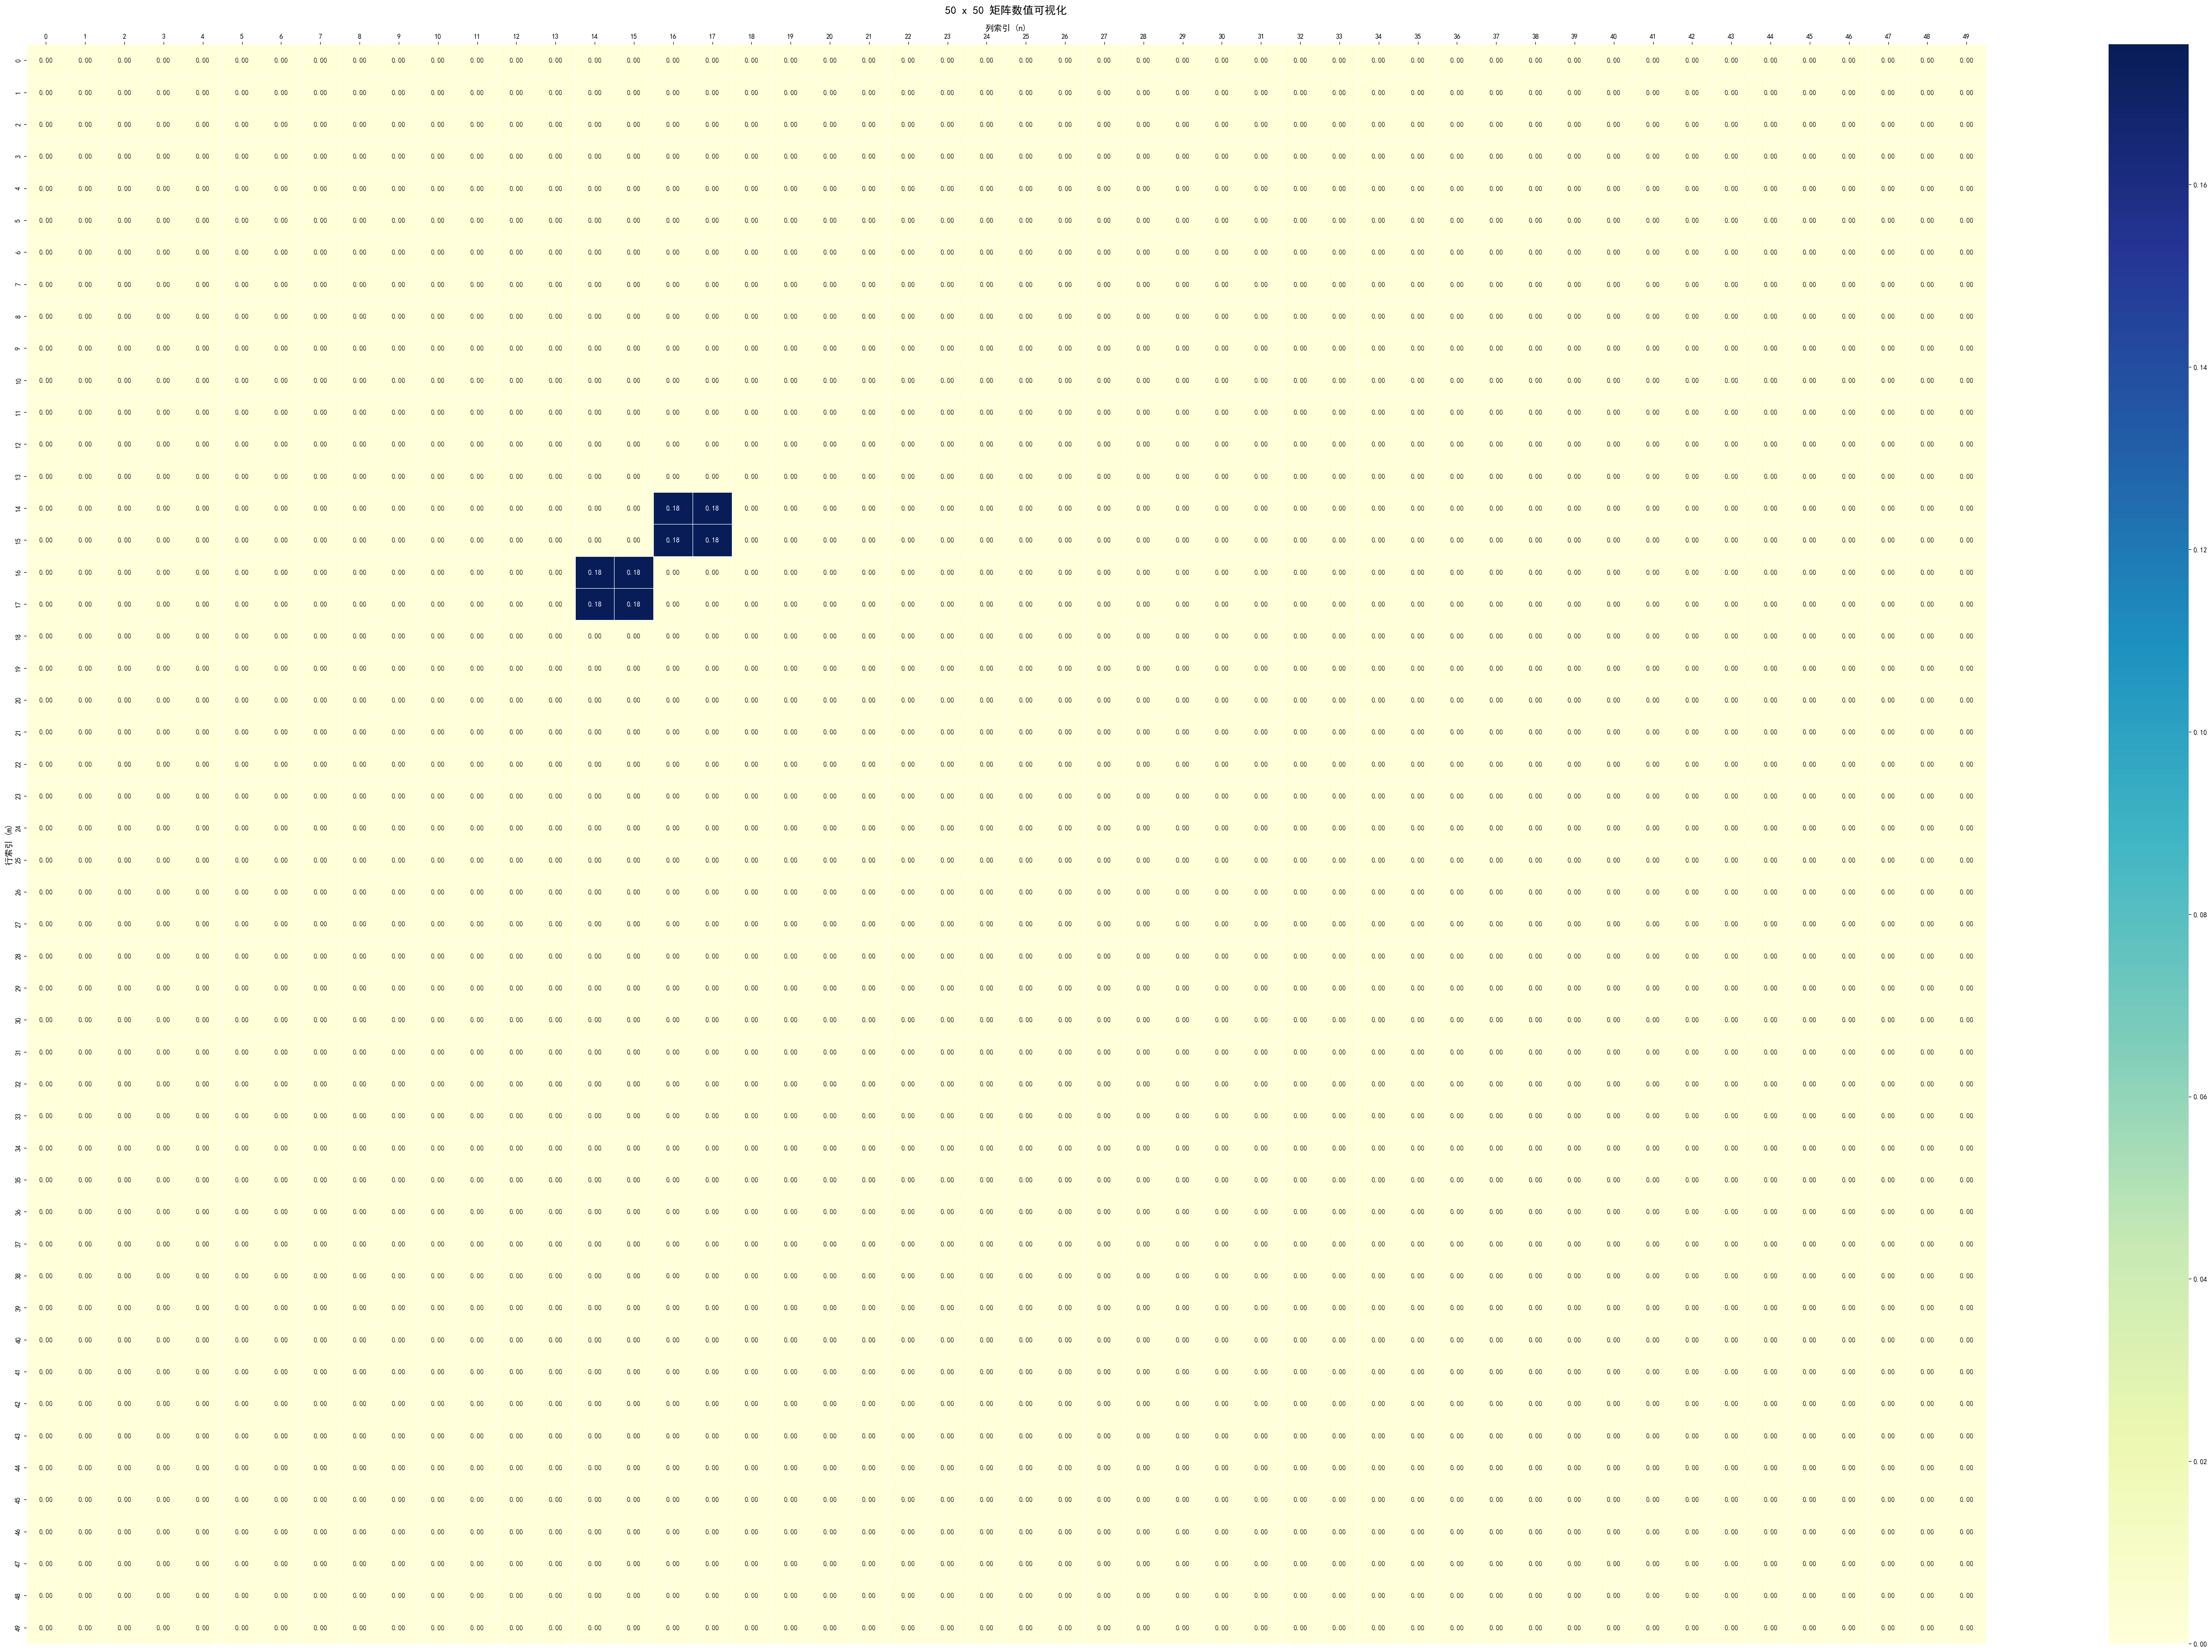

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_matrix(matrix):
    """
    可视化 m*n 矩阵的数值大小
    """
    # 获取矩阵的行数(m)和列数(n)
    m, n = matrix.shape
    
    # 设置图形的显示大小
    plt.figure(figsize=(max(n, 6), max(m/1.5, 5)))
    
    # 设置支持中文的字体（如果你的系统不支持，可以注释掉这行或者替换字体）
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

    # 绘制热力图
    # annot=True: 在每个方格内显示数值
    # fmt=".2f": 数值格式（.2f表示保留两位小数，如果矩阵是整数可以用 "d"）
    # cmap="YlGnBu": 颜色映射，YlGnBu是从黄到绿再到蓝，颜色越深代表数值越大
    # linewidths=0.5: 格子之间的网格线宽度
    ax = sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)

    # 设置标题和坐标轴
    plt.title(f'{m} x {n} 矩阵数值可视化', fontsize=16, pad=15)
    plt.xlabel('列索引 (n)', fontsize=12)
    plt.ylabel('行索引 (m)', fontsize=12)

    # 将X轴的刻度移到上方（可选，通常矩阵可视化时列号在上方更直观）
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top') 

    # 紧凑布局并显示
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":

    # 3. 调用函数进行可视化
    visualize_matrix(abs(Sigma_y1))

In [73]:

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    # N 就是 yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 对于你来说，这里应该是 4 * xshumu
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    # 注意：电极和中心区的维度不同，需要分别构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ------------- 构建总格林函数矩阵 A_DD -------------
    A_DD = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        # 从列表中取出对应 yweizhi (即 i) 的 H_q
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == yshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
            
        else:
            A_DD[i][i] = EI_device - H_q_i

        if i < yshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T
            
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r,Sigma_R, Sigma_L

